In [13]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
llm_gpt = ChatOpenAI(model='gpt-4o', temperature=0)

In [14]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

In [15]:
from typing import TypedDict
class State(TypedDict):
    weather:str
    

In [16]:
graph_builder = StateGraph(State)

In [17]:
# define node functions

def weather_node(state:State)->State:
    print("checking the weather...")
    return state

def rainy_node(state:State)->State:
    print("Its Rainsy, Take an umberela")
    return state

def sunny_node(state:State)->State:
    print("its, sunny, wear sunglasses")
    return state


In [18]:
# define routing functions

def weather_routing(state:State)->str:
    if state['weather']=='rainy':
        return 'rainy' #name of rainy the node
    elif state['weather']=='sunny':
        return 'sunny' #name of sunny the node
    else:
        raise ValueError("Invalid weather condition!")


In [19]:
# add nodes to graph

graph_builder.add_node('weather_node', weather_node)
graph_builder.add_node('rainy', rainy_node)
graph_builder.add_node('sunny', sunny_node)


In [20]:
# define edged
graph_builder.add_edge(START,'weather_node')
graph_builder.add_conditional_edges(
    "weather_node",
    weather_routing, #the routing node will route to the rainy/sunny node if rainy/sunny respectively
    ["rainy", "sunny"] #possible nodes where routing function can end up going
)
graph_builder.add_edge('rainy',END)
graph_builder.add_edge('sunny',END)


In [21]:
graph = graph_builder.compile()

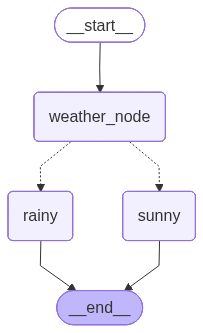

In [22]:
graph

In [23]:
print("\n-----Rainy Condition------")
initial_state_rainy = {"weather":"rainy"}

result = graph.invoke(initial_state_rainy)


-----Rainy Condition------
checking the weather...
Its Rainsy, Take an umberela


In [24]:
print("\n-----Sunny Condition------")
initial_state_rainy = {"weather":"sunny"}

result = graph.invoke(initial_state_rainy)


-----Sunny Condition------
checking the weather...
its, sunny, wear sunglasses


In [25]:
print("\n-----humid Condition------")
initial_state_rainy = {"weather":"humid"}

result = graph.invoke(initial_state_rainy)


-----humid Condition------
checking the weather...


ValueError: Invalid weather condition!

In [34]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages:Annotated[list, add_messages]
    topic:str


def get_topic(state:State)->str:
    topic = state['messages'][0].content
    print(f'----Getting Topic: {topic}-----')
    return {'topic':topic}

def decide_route(state:State)->State:
    print("---Conditional Routing----")
    topic = state['topic']
    print(topic)

    if topic.lower() in ['batman', 'superman']:
        return 'node_dc'
    if topic.lower() in ['spiderman', 'avengers']:
        return "node_marvel"
    return "node_others"


    

In [35]:
# defining nodes

def node_dc(state):
    print("-----Node DC Comics----")
    topic = state['topic']

    return {"messages":"Hellow yes happy to show you comics of: "+topic}

def node_marvel(state):
    print("-----Node Marvel Comics----")
    topic = state['topic']

    return {"messages":"Hellow yes happy to show you comics of: "+topic}

def node_others(state):
    print("-----Node DC Comics----")
    topic = state['topic']

    return {"messages":"Sorry we do not have: "+topic}



In [36]:
# adding nodes in builder
graph_builder = StateGraph(State)

graph_builder.add_node('get_topic', get_topic)
graph_builder.add_node('node_dc', node_dc)
graph_builder.add_node('node_marvel', node_marvel)
graph_builder.add_node('node_others', node_others)


In [37]:
# adding edges
graph_builder.add_edge(START, 'get_topic')
graph_builder.add_conditional_edges(
    'get_topic',
    decide_route,
    ['node_dc', 'node_marvel', 'node_others']
)

graph_builder.add_edge('node_dc', END)
graph_builder.add_edge('node_marvel', END)
graph_builder.add_edge('node_others', END)


graph = graph_builder.compile()

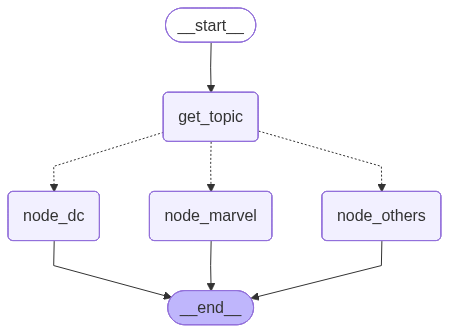

In [38]:
graph

In [39]:
def call_agent(agent, topic):
    msgs = agent.invoke({"messages":topic})

    print(msgs['messages'][-1].content)

In [40]:
call_agent(graph, 'Batman')

----Getting Topic: Batman-----
---Conditional Routing----
Batman
-----Node DC Comics----
Hellow yes happy to show you comics of: Batman


In [41]:
call_agent(graph, 'spidewrman')

----Getting Topic: spidewrman-----
---Conditional Routing----
spidewrman
-----Node DC Comics----
Sorry we do not have: spidewrman


In [42]:
call_agent(graph, 'avengers')

----Getting Topic: avengers-----
---Conditional Routing----
avengers
-----Node Marvel Comics----
Hellow yes happy to show you comics of: avengers
